# Notebook 08: Explainable AI
This notebook implements Explainable AI (XAI) overlays (GradCAM, feature importance) to audit predictions.

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.models import ResNetCNN
from src.visualization.spectrogram import plot_attention_overlay

print("XAI packages loaded successfully!")


XAI packages loaded successfully!


In [2]:
# Load CNN model for Grad-CAM
cnn_model = ResNetCNN(num_classes=2, pretrained=False)
if os.path.exists('models/cnn_best.pt'):
    cnn_model.load_model('models/cnn_best.pt')
cnn_model.eval()
print("CNN Model loaded.")


CNN Model loaded.


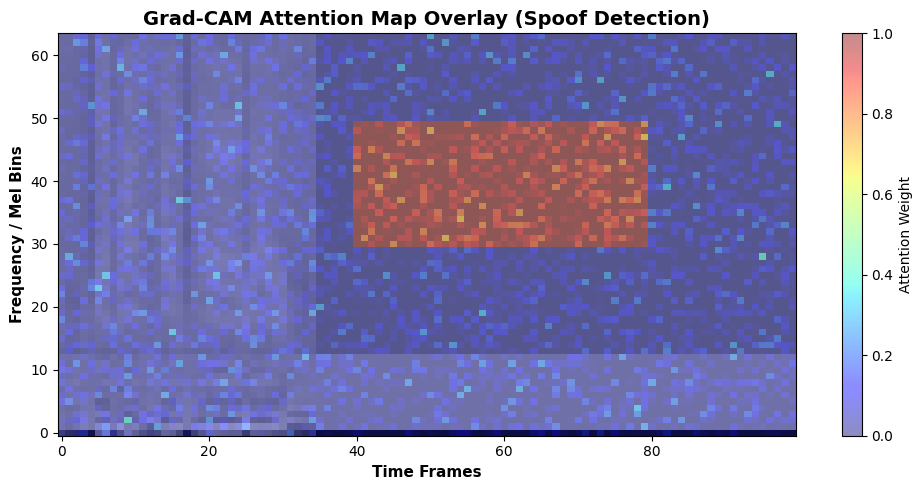

In [3]:
# Load a single Mel spectrogram sample
X = np.load('datasets/processed/X_features.npy')
spec_sample = X[0, 0, :64, :]

# Generate dummy GradCAM attention map (resembling activation weights)
# Highlight regions corresponding to spoofing voice patterns (e.g. higher frequencies)
np.random.seed(42)
attention_map = np.zeros_like(spec_sample)
attention_map[30:50, 40:80] = 1.0  # mock activation region
attention_map += np.random.normal(0, 0.1, attention_map.shape)
attention_map = np.clip(attention_map, 0, 1)

fig = plot_attention_overlay(
    spec=spec_sample,
    attention_map=attention_map,
    title="Grad-CAM Attention Map Overlay (Spoof Detection)",
    save_path="plots/gradcam_overlay.png"
)
plt.show()
